# Making Predictions

In [1]:
import chainladder as cl
import pandas as pd

This example demonstrates how you can create development patterns at a
particular ``index`` grain and apply them to another.

In this example, we can apply both an industry derived LDF or a company derived LDF to a specific triangle.

In [5]:
clrd = cl.load_sample('clrd')['CumPaidLoss']
clrd_wc = clrd[clrd['LOB'] == 'wkcomp']

industry_wc = clrd_wc.sum()

allstate_wc_industry_pattern = cl.Chainladder().fit(industry_wc).predict(clrd_wc.loc['Allstate Ins Co Grp']).ultimate_
allstate_wc_company_pattern = cl.Chainladder().fit(clrd_wc.loc['Allstate Ins Co Grp']).ultimate_

df = pd.DataFrame(
    {
        "allstate_wc_industry_pattern": allstate_wc_industry_pattern.to_frame(
        ).iloc[:, 0],
        "allstate_wc_company_pattern": allstate_wc_company_pattern.to_frame(
        ).iloc[:, 0],
    }
).fillna(0)
df.index = pd.to_datetime(df.index).year
df.index.name = "Origin Year"
df.reset_index()

,Origin Year,allstate_wc_industry_pattern,allstate_wc_company_pattern
0,1988,325322.000000,325322.000000
1,1989,276660.740492,276863.571154
2,1990,264559.787229,268960.552632
3,1991,252620.869201,258402.289056
4,1992,173864.635638,180150.887317
5,1993,99493.416499,104286.313106
6,1994,112350.433124,119003.414168
7,1995,123829.928837,132157.175486
8,1996,83778.038787,90947.646834
9,1997,2837.012601,3110.281691


<Figure size 640x480 with 0 Axes>

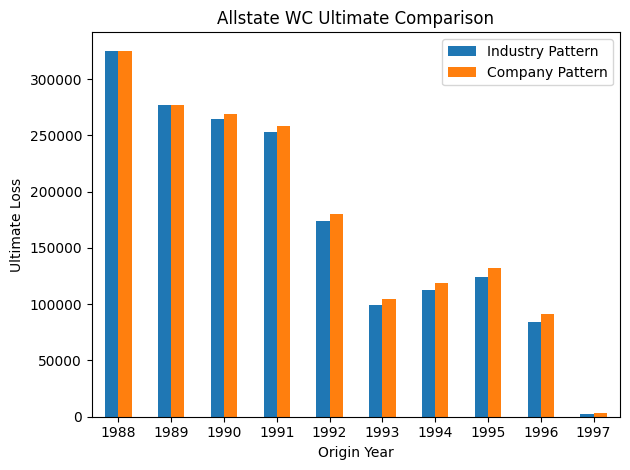

In [6]:
import matplotlib.pyplot as plt

plot_df = df[[
    "allstate_wc_industry_pattern",
    "allstate_wc_company_pattern"
]].rename(columns={
    "allstate_wc_industry_pattern": "Industry Pattern",
    "allstate_wc_company_pattern": "Company Pattern"
})

# Create bar chart
plot_df.plot(kind='bar')

# Labels and title
plt.title("Allstate WC Ultimate Comparison")
plt.ylabel("Ultimate Loss")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()